In [1]:
import numpy as np 
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import math
import pandas as pd 
import matplotlib.pyplot as plt

# import seaborn as sns
import sklearn.metrics as metrics
%matplotlib inline
import os
# from pandas_ml import ConfusionMatrix

In [2]:
df_train = pd.read_csv("./data/df_train.csv",index_col=0)
# df_train2 = df_train.drop(df_train[df_train['attack_type'] == 1].index)
df_train_1 = df_train[df_train['attack_type'].isin([1])]
df_train_0 = df_train[df_train['attack_type'].isin([0])]

df_ma, df_mi = train_test_split(df_train_1, test_size=0.1, random_state=42)
df_train2 = df_train_0.append(df_mi)

X_train, X_test, y_train, y_test = train_test_split(df_train2.drop(['attack_type'],axis=1), df_train2['attack_type'], test_size=0.2, random_state=42)

In [3]:
df_train2.shape

(84201, 41)

In [4]:
Y_train = y_train
Y_test = y_test
dict = {}
for i in Y_train:
    dict.update({i:dict.get(i,0)+1})
dict

{0: 61648, 1: 5712}

In [5]:
from sklearn.ensemble import AdaBoostClassifier
from imblearn.ensemble import EasyEnsembleClassifier

from imblearn.ensemble import BalancedBaggingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.ensemble import RUSBoostClassifier

In [6]:
def BalanceCascade(X_train, y_train, X_test, num):
    X_train = X_train.values
    X_test = X_test.values
    y_train = y_train.values
    negnum = y_train[y_train == 0].shape[0]
    posnum = y_train[y_train == 1].shape[0]
    neg_index = np.argwhere(y_train == 0).reshape(negnum, )
    pos_index = np.argwhere(y_train == 1).reshape(posnum, )
    pos_train = X_train[pos_index, :]

    FP = pow(posnum / negnum, 1 / (num - 1))
    classifiers = {};
    thresholds = {};
    test_prob = np.empty((X_test.shape[0], num))
    for i in range(num):
        classifiers[i] = AdaBoostClassifier()
        neg_train_index = np.random.permutation(neg_index)[:posnum]
        neg_train = X_train[neg_train_index, :]
        cur_X_train = np.r_[pos_train, neg_train]
        cur_y_train = np.r_[y_train[pos_index], y_train[neg_train_index]]
        classifiers[i].fit(cur_X_train, cur_y_train)
        predict_result = classifiers[i].predict_proba(X_train[neg_index, :])[:, -1]
        thresholds[i] = np.sort(predict_result)[int(neg_index.shape[0] * (1 - FP))] - 0.5
        neg_index = np.argwhere(predict_result >= (thresholds[i] + 0.5)).reshape(-1, )
        test_prob[:, i] = classifiers[i].predict_proba(X_test)[:, -1] + thresholds[i]
#         print("No.{} Classifier Training Finished".format(i))
    test_prob_result = np.average(test_prob, axis=1)
    test_prob_result = np.around(test_prob_result, decimals=0, out=None)
    test_prob_result = pd.DataFrame(test_prob_result)
    return test_prob_result

In [10]:
accuracy_test22 = np.empty((20))
accuracy_train22 = np.empty((20))

accuracy_test3 = np.empty((20))
accuracy_train3 = np.empty((20))

accuracy_test4 = np.empty((20))
accuracy_train4 = np.empty((20))

accuracy_test5 = np.empty((20))
accuracy_train5 = np.empty((20))

accuracy_test6 = np.empty((20))
accuracy_train6 = np.empty((20))

# accuracy_test7 = np.empty((20))
# accuracy_train7 = np.empty((20))

# accuracy_test8 = np.empty((20))
# accuracy_train8 = np.empty((20))

i = 1
while i<=20:
    model22 = EasyEnsembleClassifier(n_estimators=i, n_jobs=1,
             replacement=False, sampling_strategy='auto',verbose=0, warm_start=False,
                                     base_estimator=AdaBoostClassifier(n_estimators=5,random_state=42))
    model22.fit(X_train,Y_train)
    final_ans_test = model22.predict(X_test)
    acc = metrics.accuracy_score(Y_test,final_ans_test)
    accuracy_test22[i-1] = acc
    final_ans_train = model22.predict(X_train)
    acc = metrics.accuracy_score(Y_train,final_ans_train)
    accuracy_train22[i-1] = acc
    print("a%d"%i,end=" ")
    
    
    model3 = BalancedBaggingClassifier(n_estimators=i, random_state=42)
    model3.fit(X_train,Y_train)
    final_ans_test = model3.predict(X_test)
    acc = metrics.accuracy_score(Y_test,final_ans_test)
    accuracy_test3[i-1] = acc
    final_ans_train = model3.predict(X_train)
    acc = metrics.accuracy_score(Y_train,final_ans_train)
    accuracy_train3[i-1] = acc
    print("b%d"%i,end=" ")
    
    model4 = EasyEnsembleClassifier(n_estimators=i, n_jobs=1,
             replacement=False, sampling_strategy='auto',verbose=0, warm_start=False,
                                     base_estimator=DecisionTreeClassifier())
    model4.fit(X_train,Y_train)
    final_ans_test = model4.predict(X_test)
    acc = metrics.accuracy_score(Y_test,final_ans_test)
    accuracy_test4[i-1] = acc
    final_ans_train = model4.predict(X_train)
    acc = metrics.accuracy_score(Y_train,final_ans_train)
    accuracy_train4[i-1] = acc
    print("c%d"%i,end=" ")
    
#     model5 = EasyEnsembleClassifier(n_estimators=i, n_jobs=1,
#              replacement=False, sampling_strategy='auto',verbose=0, warm_start=False,
#                                      base_estimator=KNeighborsClassifier())
#     model5.fit(X_train,Y_train)
#     final_ans_test = model5.predict(X_test)
#     acc = metrics.accuracy_score(Y_test,final_ans_test)
#     accuracy_test5[i-1] = acc
#     final_ans_train = model5.predict(X_train)
#     acc = metrics.accuracy_score(Y_train,final_ans_train)
#     accuracy_train5[i-1] = acc
#     print("d%d"%i,end=" ")
    
    model6 = EasyEnsembleClassifier(n_estimators=i, n_jobs=1,
             replacement=False, sampling_strategy='auto',verbose=0, warm_start=False,
                                     base_estimator=RandomForestClassifier(n_estimators=20))
    model6.fit(X_train,Y_train)
    final_ans_test = model6.predict(X_test)
    acc = metrics.accuracy_score(Y_test,final_ans_test)
    accuracy_test6[i-1] = acc
    final_ans_train = model6.predict(X_train)
    acc = metrics.accuracy_score(Y_train,final_ans_train)
    accuracy_train6[i-1] = acc
    print("e%d"%i,end=" ")
    
#     final_ans_test6 = BalanceCascade(X_train, y_train, X_test, i+1)
#     acc = metrics.accuracy_score(Y_test,final_ans_test6)
#     accuracy_test6[i-1] = acc
#     final_ans_train6 = BalanceCascade(X_train, y_train, X_train, i+1)
#     acc = metrics.accuracy_score(Y_train,final_ans_train6)
#     accuracy_train6[i-1] = acc
#     print("c%d"%i,end=" ")
    
#     final_ans_test6 = np.array(final_ans_test6).flatten()
#     final_ans_train6 = np.array(final_ans_train6).flatten()
    
# #     final_ans_test = (model22.predict(X_test) + model3.predict(X_test) + final_ans_test6)/3.0
#     final_ans_test = np.around((model22.predict(X_test) + model3.predict(X_test) + final_ans_test6)/3.0)
#     acc = metrics.accuracy_score(Y_test,final_ans_test)
#     accuracy_test7[i-1] = acc
#     final_ans_train =np.around((model22.predict(X_train) + model3.predict(X_train) + final_ans_train6)/3.0)
#     acc = metrics.accuracy_score(Y_train,final_ans_train)
#     accuracy_train7[i-1] = acc
    
#     final_ans_test = np.around(0.2*model22.predict(X_test) + 0.6*model3.predict(X_test) + 0.2*final_ans_test6)
#     acc = metrics.accuracy_score(Y_test,final_ans_test)
#     accuracy_test8[i-1] = acc
#     final_ans_train =np.around(0.2*model22.predict(X_train) + 0.6*model3.predict(X_train) + 0.2*final_ans_train6)
#     acc = metrics.accuracy_score(Y_train,final_ans_train)
#     accuracy_train8[i-1] = acc
#     print("d%d"%i,end=" ")
    
    
    i = i+1
    

a1 b1 c1 e1 a2 b2 c2 e2 a3 b3 c3 e3 a4 b4 c4 e4 a5 b5 c5 e5 a6 b6 c6 e6 a7 b7 c7 e7 a8 b8 c8 e8 a9 b9 c9 e9 a10 b10 c10 e10 a11 b11 c11 e11 a12 b12 c12 e12 a13 b13 c13 e13 a14 b14 c14 e14 a15 b15 c15 e15 a16 b16 c16 e16 a17 b17 c17 e17 a18 b18 c18 e18 a19 b19 c19 e19 a20 b20 c20 e20 

In [11]:
final_ans_test

array([0, 0, 0, ..., 0, 1, 0], dtype=int64)

In [12]:
round(2.3/3.0)

1

In [13]:
# sns.set()
import warnings


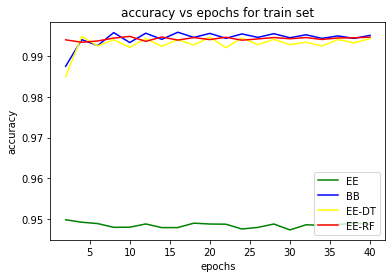

In [14]:
x = np.empty((20))
j = 1
while j<=20:
    x[j-1] = j*2
    j = j+1

# plt.plot(x, accuracy_test, label="adaboost test accuracy")
# plt.plot(x,accuracy_train,label="adaboost train accuracy")
# plt.plot(x, accuracy_test, c= 'red', label = "test", linestyle='-')
# plt.plot(x,accuracy_train, c= 'green', label ="train", linestyle='-')

# plt.plot(x, accuracy_train, c= 'red', label = "AB", linestyle='-')
# plt.plot(x, accuracy_train2, c= 'green', label = "EE", linestyle='-')
plt.plot(x, accuracy_train22, c= 'green', label = "EE", linestyle='-')
plt.plot(x, accuracy_train3, c= 'blue', label = "BB", linestyle='-')
plt.plot(x, accuracy_train4, c= 'yellow', label = "EE-DT", linestyle='-')
# plt.plot(x, accuracy_train5, c= 'black', label = "EE-KNN", linestyle='-')
plt.plot(x, accuracy_train6, c= 'red', label = "EE-RF", linestyle='-')
# plt.plot(x, accuracy_train7, c= 'red', label = "F1", linestyle='-')
# plt.plot(x, accuracy_train8, c= 'yellow', label = "F2", linestyle='-')
# plt.plot(1,acc_test,'yo')
# plt.plot(1,acc_train,'go')
plt.xlabel('epochs')  
plt.ylabel('accuracy') 
  
# giving a title to my graph 
plt.title('accuracy vs epochs for train set') 
plt.legend(loc = 'lower right')
# function to show the plot 
plt.show() 


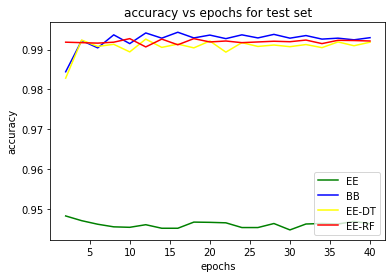

In [15]:
# Task 3

x = np.empty((20))
j = 1
while j<=20:
    x[j-1] = j*2
    j = j+1

# plt.plot(x, accuracy_test, label="adaboost test accuracy")
# plt.plot(x,accuracy_train,label="adaboost train accuracy")
# plt.plot(x, accuracy_test, c= 'red', label = "test", linestyle='-')
# plt.plot(x,accuracy_train, c= 'green', label ="train", linestyle='-')

# plt.plot(x, accuracy_test, c= 'red', label = "AB", linestyle='-')
plt.plot(x, accuracy_test22, c= 'green', label = "EE", linestyle='-')
plt.plot(x, accuracy_test3, c= 'blue', label = "BB", linestyle='-')
plt.plot(x, accuracy_test4, c= 'yellow', label = "EE-DT", linestyle='-')
# plt.plot(x, accuracy_test5, c= 'black', label = "EE-KNN", linestyle='-')
plt.plot(x, accuracy_test6, c= 'red', label = "EE-RF", linestyle='-')
# plt.plot(x, accuracy_test7, c= 'red', label = "F1", linestyle='-')
# plt.plot(x, accuracy_test8, c= 'yellow', label = "F2", linestyle='-')
# plt.plot(1,acc_test,'yo')
# plt.plot(1,acc_train,'go')
plt.xlabel('epochs')  
plt.ylabel('accuracy') 
  
# giving a title to my graph 
plt.title('accuracy vs epochs for test set') 
plt.legend(loc = 'lower right')
# function to show the plot 
plt.show() 